# A detailed report of the EDA is provided in a separate MD file


# Dependencies


In [130]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.stats.api as sms
import colorsys
import warnings
from geopy.distance import great_circle
from folium.plugins import HeatMap, MarkerCluster

warnings.filterwarnings("ignore")

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=0.8)
sns.set_palette(sns.color_palette("deep"))
sns.set_theme(style="whitegrid")


# Dataset


In [131]:
df = pd.read_csv("../artifacts/data/02-preprocessed/train_df.csv")

In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12460 entries, 0 to 12459
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   url                  12460 non-null  object 
 1   house_type           12460 non-null  object 
 2   bathrooms            12460 non-null  int64  
 3   bedrooms             12460 non-null  int64  
 4   price                12460 non-null  float64
 5   locality             12460 non-null  object 
 6   lat                  12460 non-null  float64
 7   lng                  12460 non-null  float64
 8   condition            12460 non-null  object 
 9   furnishing           12460 non-null  object 
 10  24_hour_electricity  12460 non-null  int64  
 11  air_conditioning     12460 non-null  int64  
 12  apartment            12460 non-null  int64  
 13  balcony              12460 non-null  int64  
 14  chandelier           12460 non-null  int64  
 15  dining_area          12460 non-null 

In [133]:
df.head(2)

,url,house_type,bathrooms,bedrooms,price,locality,lat,lng,condition,furnishing,24_hour_electricity,air_conditioning,apartment,balcony,chandelier,dining_area,dishwasher,hot_water,kitchen_cabinets,kitchen_shelf,microwave,pop_ceiling,pre_paid_meter,refrigerator,tv,tiled_floor,wardrobe,wi_fi
0,https://jiji.com.gh/manet-junction/houses-apar...,Apartment,2,3,8000.0,Spintex,5.637614,-0.126606,New,Unfurnished,1,1,0,1,1,0,0,1,1,1,0,1,1,0,0,1,1,0
1,https://jiji.com.gh/airport-residential-area/h...,Apartment,2,2,6000.0,Airport Residential Area,5.606105,-0.186036,New,Semi-Furnished,1,1,1,1,0,0,0,1,1,0,0,1,1,0,0,1,1,0


In [134]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
bathrooms,12460.0,2.636116,1.506871,1.000000,1.000000,2.000000,4.000000,20.00000
bedrooms,12460.0,2.546950,1.415278,1.000000,2.000000,2.000000,3.000000,20.00000
price,12460.0,10725.537560,15416.373820,160.000000,2200.000000,4500.000000,12400.000000,176000.00000
lat,12460.0,5.779447,1.785080,5.532814,5.583166,5.635828,5.669425,36.97880
lng,12460.0,0.013789,3.120399,-25.105905,-0.217044,-0.161359,-0.126606,39.60245
24_hour_electricity,12460.0,0.743660,0.436629,0.000000,0.000000,1.000000,1.000000,1.00000
air_conditioning,12460.0,0.494302,0.499988,0.000000,0.000000,0.000000,1.000000,1.00000
apartment,12460.0,0.127769,0.333846,0.000000,0.000000,0.000000,0.000000,1.00000
balcony,12460.0,0.542215,0.498235,0.000000,0.000000,1.000000,1.000000,1.00000
chandelier,12460.0,0.281942,0.449963,0.000000,0.000000,0.000000,1.000000,1.00000


# Plotting Functions


In [ ]:
def plot_distribution(df, col, title=None):
    sns.set_theme(style="ticks")
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.histplot(
        df[col], bins=60, kde=True, color=sns.color_palette("rocket_r", 1)[0], ax=ax
    )
    median = df[col].median()
    ax.axvline(median, ls="--", lw=1.2, color="black")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    sns.despine(trim=True)
    ax.grid(False)
    ax.ticklabel_format(axis="x", style="plain")
    plt.title(title or f"Distribution of {col}")
    plt.show()


def plot_scatter(df, x, y, title=None):
    fig, ax = plt.subplots()
    sns.scatterplot(data=df, x=x, y=y, alpha=0.6, palette="Set2", ax=ax)
    ax.set_title(title or f"{y} vs {x}")
    plt.tight_layout()
    plt.show()


def plot_count(df, column, top_n=None, title=None):
    if top_n:
        top_cats = df[column].value_counts().head(top_n).index
        data = df[df[column].isin(top_cats)]
    else:
        data = df

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.countplot(
        data=data,
        y=column,
        order=data[column].value_counts().index,
        palette="muted",
        ax=ax,
    )
    ax.set_title(title or f"Count of {column}")
    plt.tight_layout()
    plt.show()


def plot_categorical_vs_numeric(df, cat_col, num_col, top_n=10):
    """Bar plot for categorical vs numeric (e.g., locality vs price)"""
    # Get top N categories by mean
    top_cats = df.groupby(cat_col)[num_col].mean().nlargest(top_n).index
    data = df[df[cat_col].isin(top_cats)]

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(
        data=data,
        x=cat_col,
        y=num_col,
        estimator=np.mean,
        errorbar=None,
        palette="viridis",
        ax=ax,
    )
    ax.set_title(f"{cat_col} by Average {num_col}")
    ax.set_xlabel(cat_col)
    ax.set_ylabel(f"Average {num_col}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


# Price Analysis


In [136]:
df.price.describe().T

count     12460.00000
mean      10725.53756
std       15416.37382
min         160.00000
25%        2200.00000
50%        4500.00000
75%       12400.00000
max      176000.00000
Name: price, dtype: float64

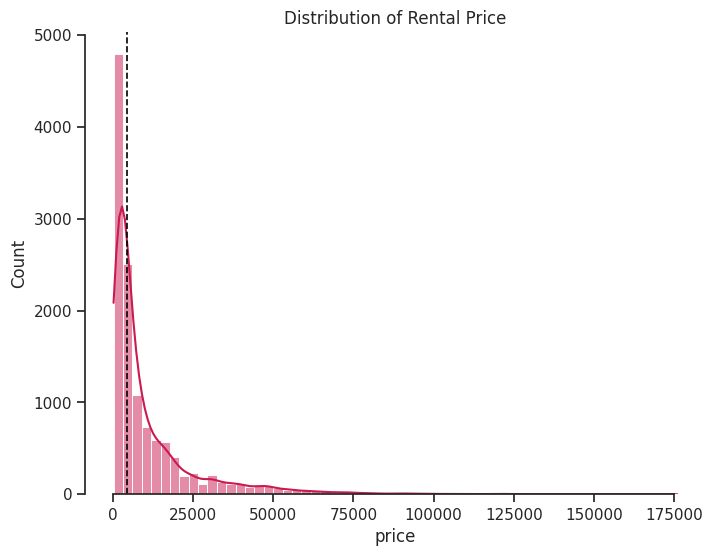

In [137]:
plot_distribution(df, "price", title="Distribution of Rental Price")

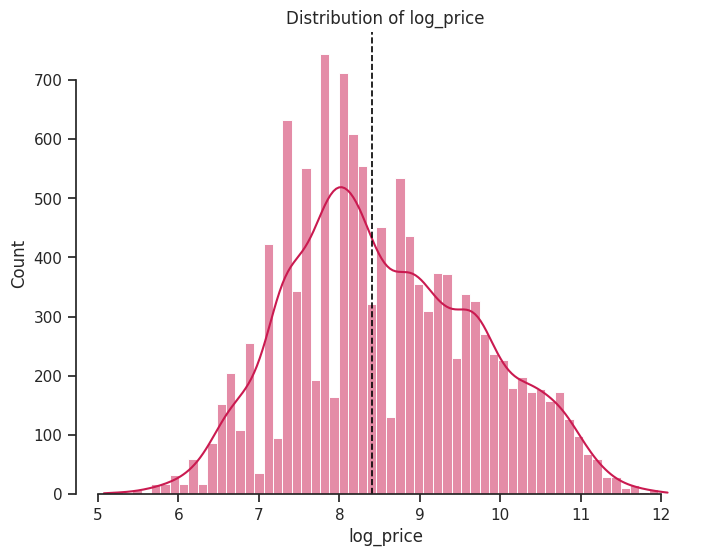

In [138]:
df["log_price"] = np.log(df.price)
plot_distribution(df, "log_price")

# Location Analysis


In [139]:
top_cities = df["locality"].value_counts().head(20).index
df_top_cities = (
    df[df["locality"].isin(top_cities)]["locality"]
    .value_counts()
    .to_frame()
    .reset_index()
)
df_top_cities

,locality,count
0,East Legon,1378
1,Spintex,1039
2,Teshie,1024
3,Adenta,708
4,Accra Metropolitan,683
5,Tema Metropolitan,650
6,Ashaley Botwe,493
7,Airport Residential Area,450
8,Adjiriganor,449
9,Weija,426


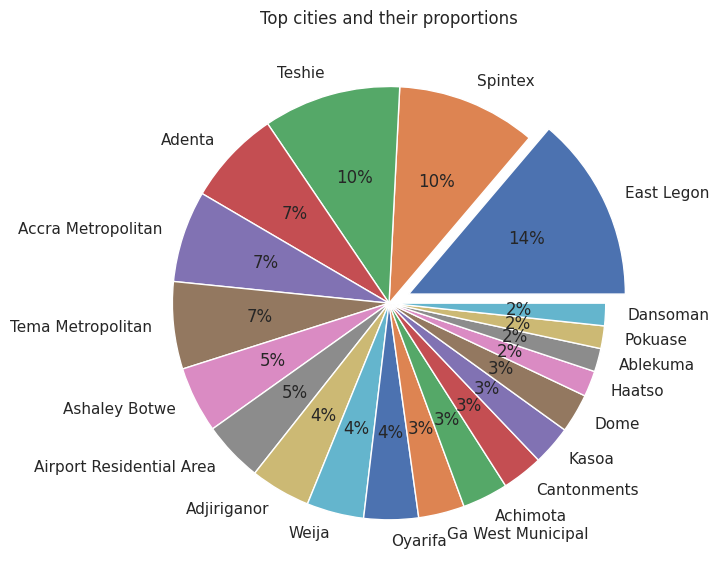

In [140]:
plt.figure()
exp = [0.1] + [0] * (df_top_cities.shape[0] - 1)
plt.pie(
    df_top_cities["count"],
    labels=df_top_cities["locality"],
    explode=exp,
    autopct="%.0f%%",
)

plt.title("Top cities and their proportions")
plt.tight_layout()
plt.show()

In [141]:
# Proximity to city center (CANTONMENTS)
CENTER = [5.577412, -0.178909]


def distance(lat, lng):
    """Calcualte distance between CENTER and any points using great circle distance

    Args:
        lat (_type_): Latitude of point
        lng (_type_): Longitude of point
    """
    return great_circle(CENTER, (lat, lng)).km


df["distance_to_center"] = df.apply(lambda x: distance(x.lat, x.lng), axis=1)

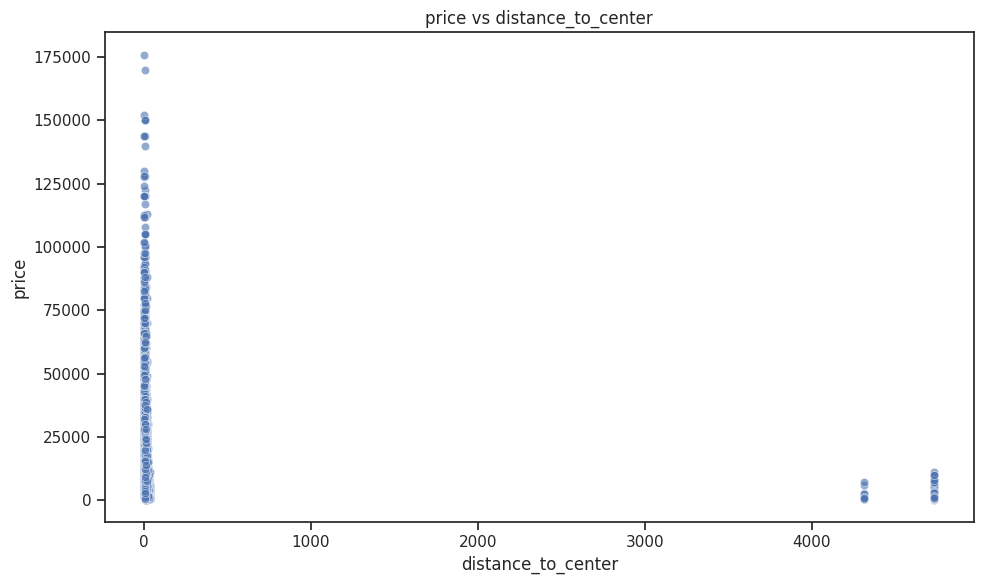

In [142]:
plot_scatter(df=df, x="distance_to_center", y="price")

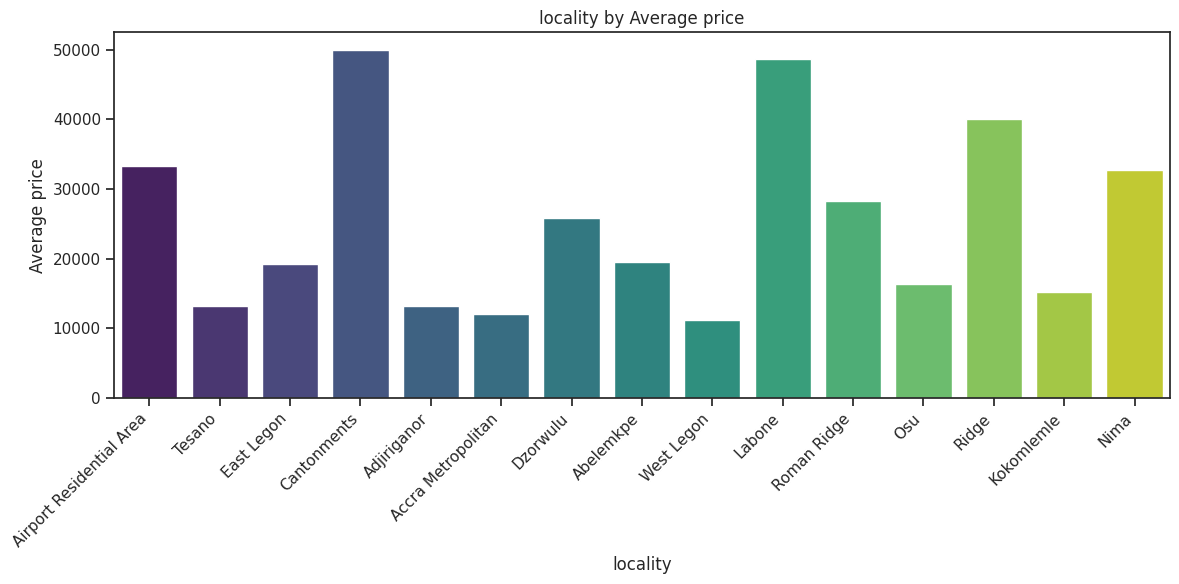

In [143]:
plot_categorical_vs_numeric(df, "locality", "price", top_n=15)

In [144]:
locality_table = []
n = 20

top_locality = df["locality"].value_counts().index[:n]
for b in top_locality:
    locality_table.append(df[df["locality"] == b]["price"].describe().T)

pd.DataFrame(locality_table, index=df["locality"].value_counts().index[:n]).sort_values(
    by="mean", ascending=False
)


,count,mean,std,min,25%,50%,75%,max
locality,,,,,,,,
Cantonments,306.0,50012.843137,24437.712320,4200.0,33525.0,45950.0,61175.0,152000.0
Airport Residential Area,450.0,33292.440000,25304.651240,1200.0,15000.0,27800.0,46695.0,150000.0
East Legon,1378.0,19255.642235,17642.305356,300.0,7000.0,14000.0,26000.0,169874.0
Adjiriganor,449.0,13196.093541,13034.283679,800.0,4000.0,8500.0,18000.0,84000.0
Accra Metropolitan,683.0,12022.715959,13618.357034,300.0,3500.0,8000.0,15560.5,150000.0
Spintex,1039.0,9182.102984,8049.345646,450.0,3500.0,7000.0,12443.0,60000.0
Teshie,1024.0,8514.205078,10932.414060,350.0,1700.0,4000.0,10425.0,91000.0
Tema Metropolitan,650.0,7598.947692,9960.291319,250.0,2500.0,4000.0,8000.0,113000.0
Achimota,341.0,7574.982405,8602.007404,300.0,1800.0,3800.0,11600.0,65000.0


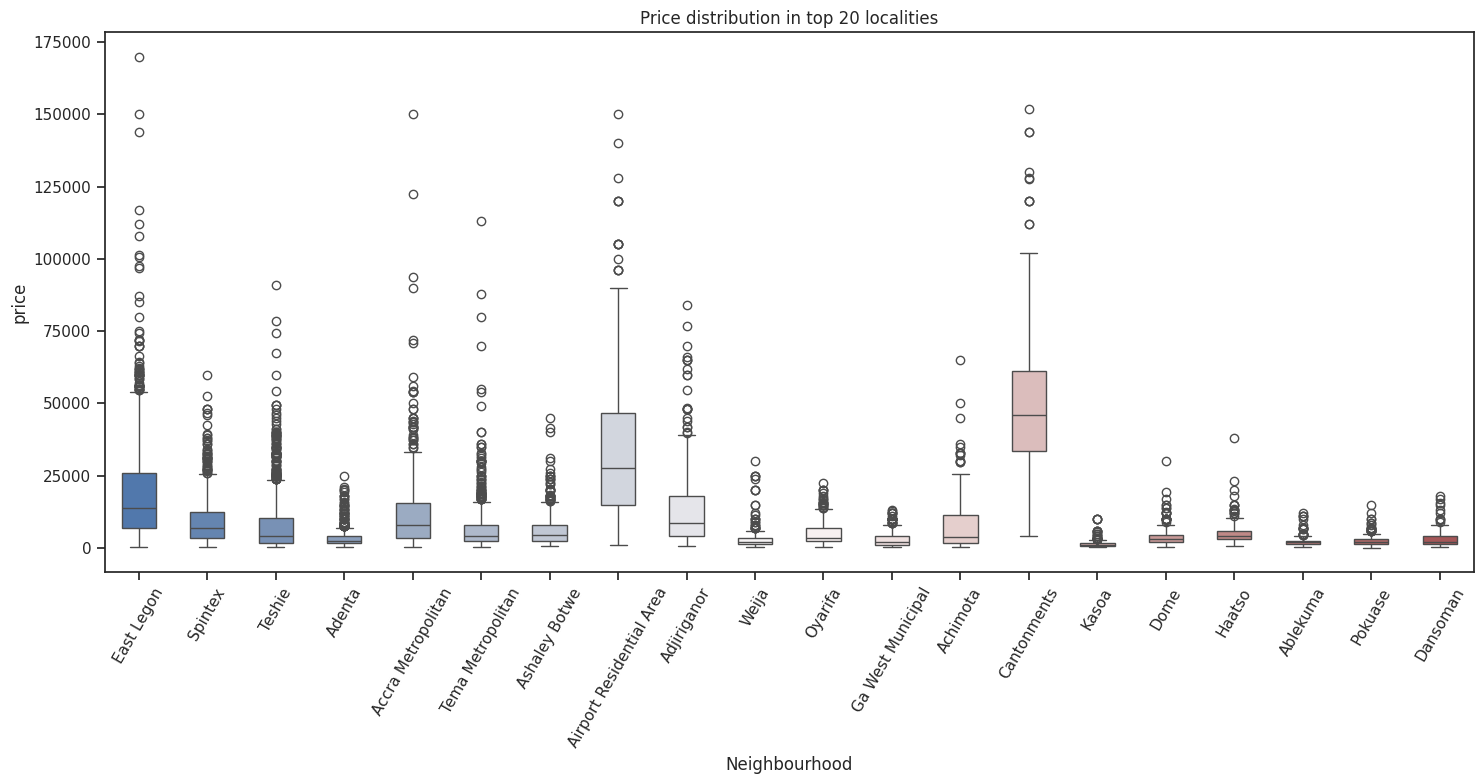

In [145]:
plt.figure(num=2, figsize=(15, 8))
sns.boxplot(
    x="locality",
    y="price",
    data=df,
    order=top_cities,
    width=0.5,
    palette="vlag",
    native_scale=True,
)
plt.title("Price distribution in top 20 localities")
plt.xlabel("Neighbourhood")
plt.xticks(rotation=60)
plt.tight_layout()
plt.savefig("top_locations_prices.png")
plt.show()


# House Features Analysis


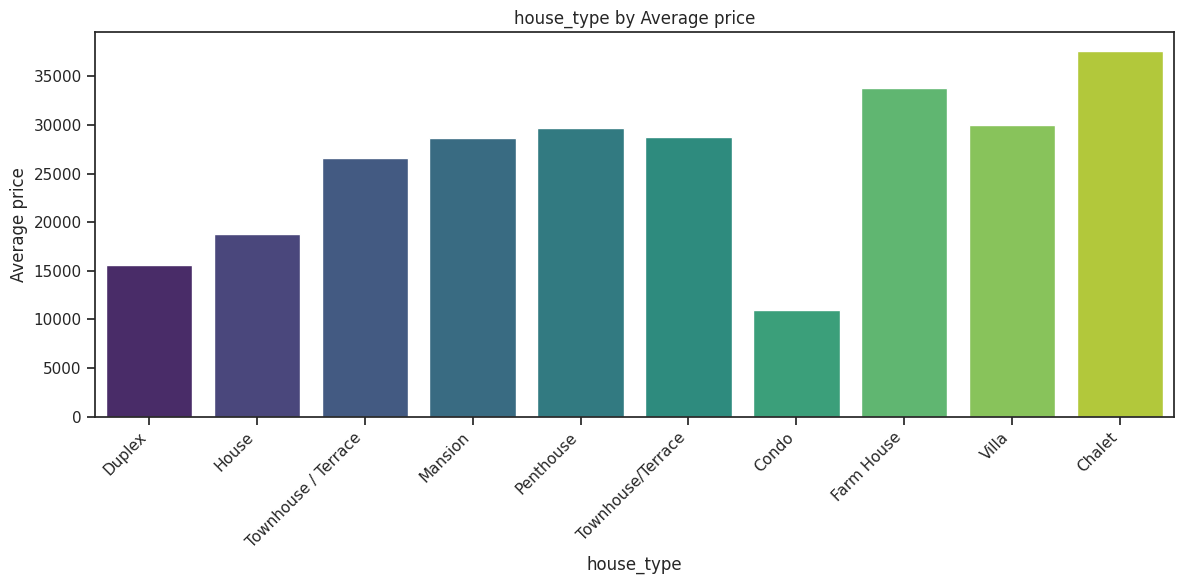

In [ ]:
plot_categorical_vs_numeric(df=df, cat_col="house_type", num_col="price")

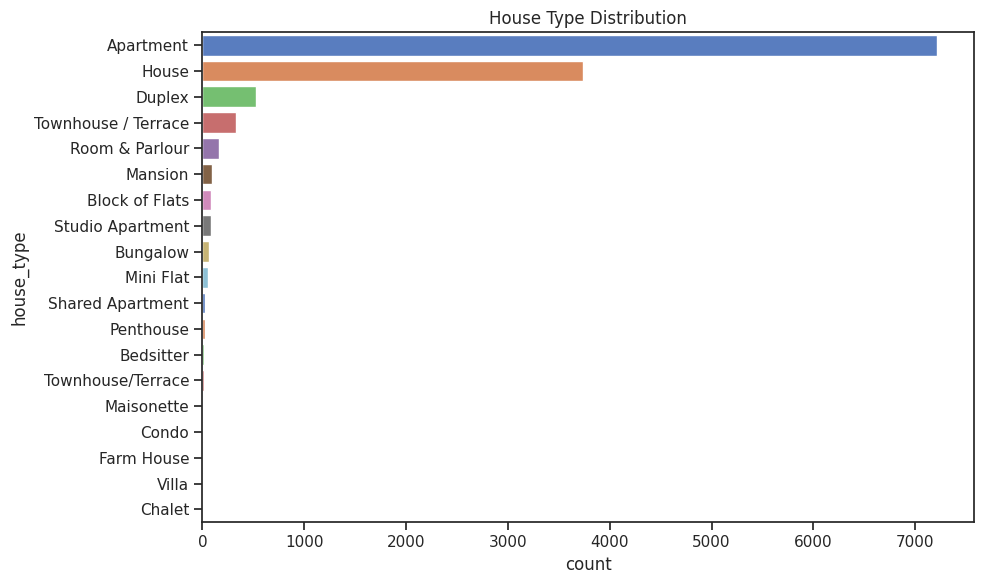

In [147]:
plot_count(df, column="house_type", title="House Type Distribution")

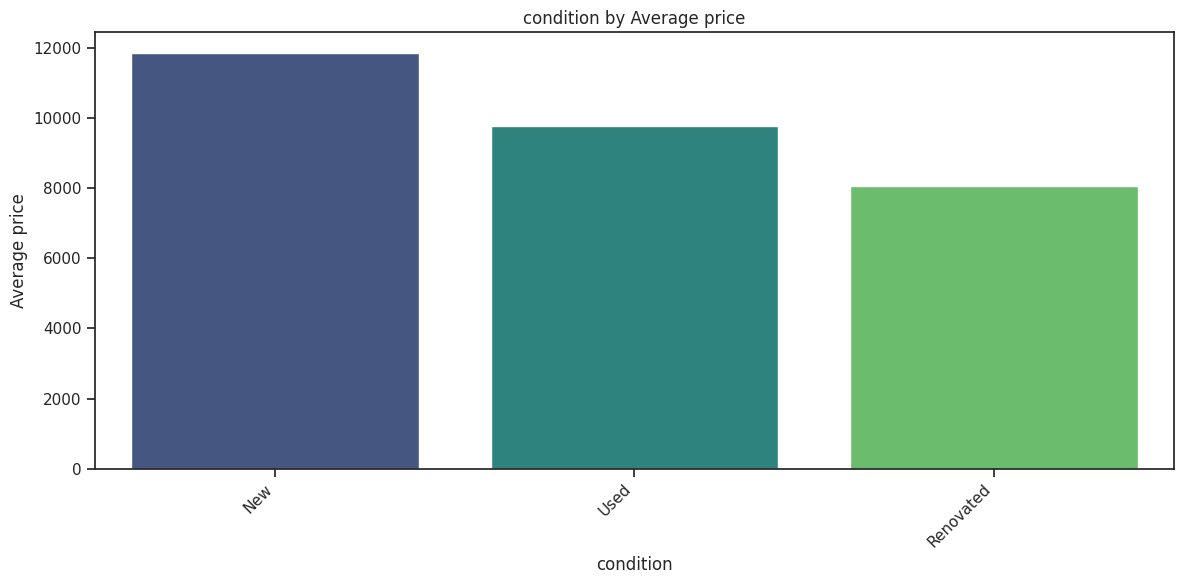

In [148]:
plot_categorical_vs_numeric(df, "condition", "price")


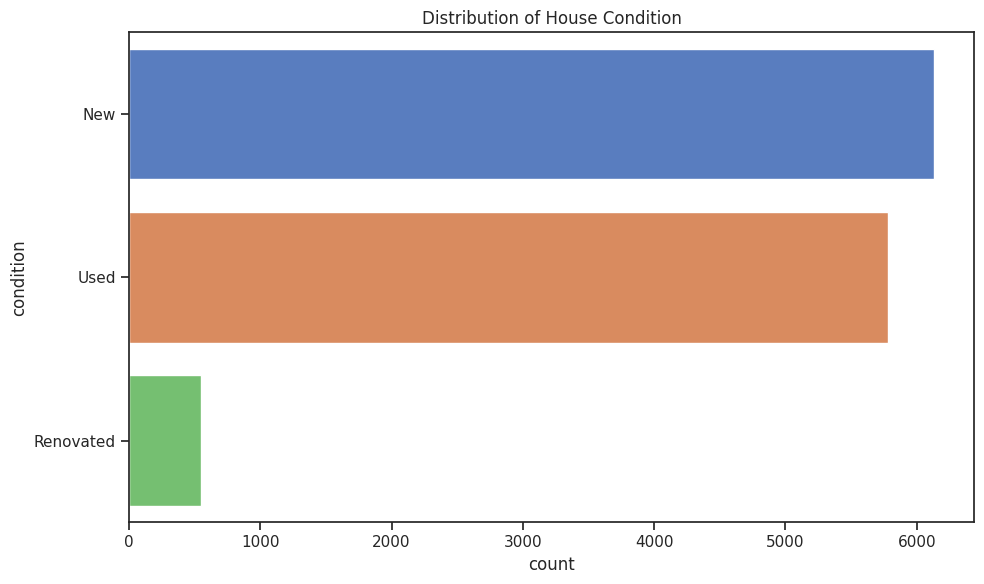

In [149]:
plot_count(df=df, column="condition", title="Distribution of House Condition")

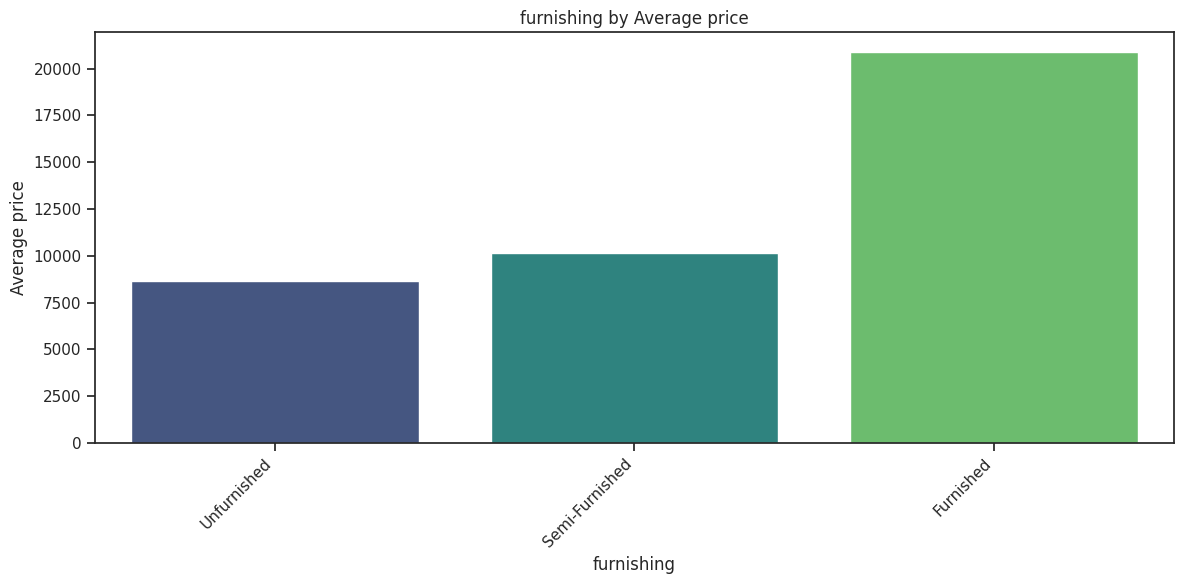

In [150]:
plot_categorical_vs_numeric(df, "furnishing", "price")


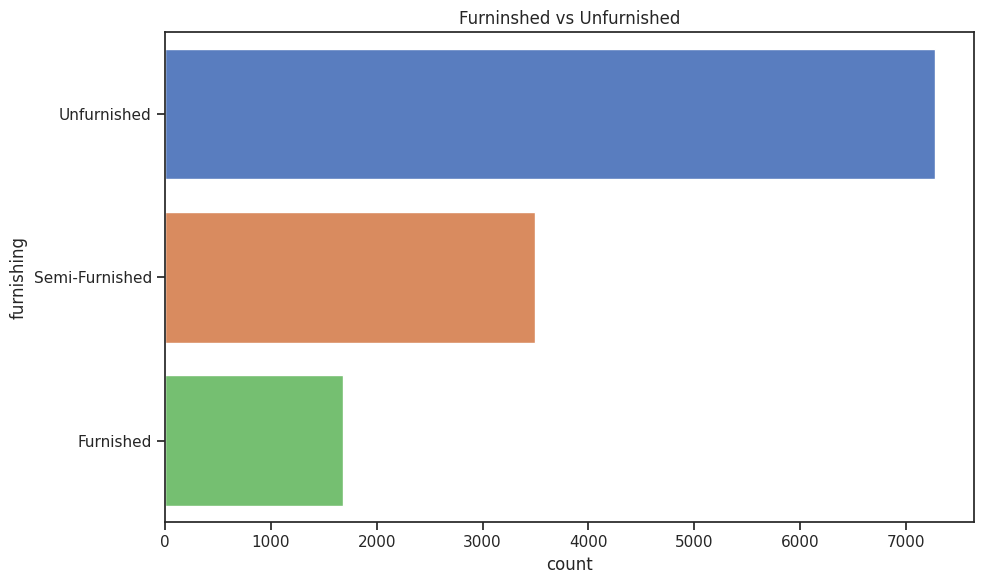

In [151]:
plot_count(df=df, column="furnishing", title="Furninshed vs Unfurnished")